In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv(r"C:\Users\Dr.Sumedha\Downloads\wine_data.csv", header=None,usecols=[0,1,2])
df.columns=["Class label", "Alcohol","Malic acid"]


In [3]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

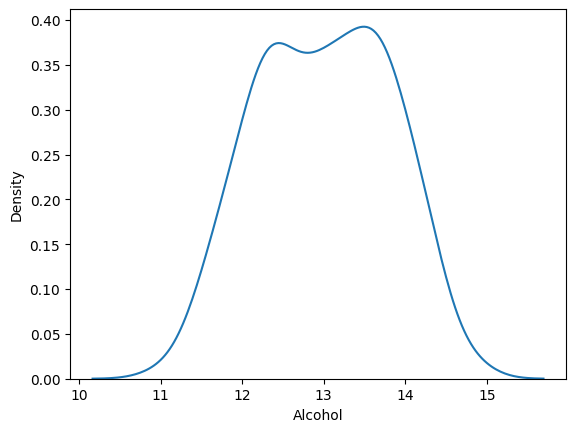

In [4]:
sns.kdeplot(df["Alcohol"])

<Axes: xlabel='Malic acid', ylabel='Density'>

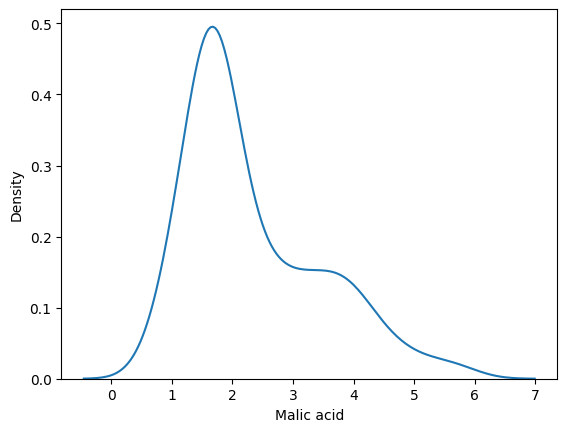

In [5]:
sns.kdeplot(df["Malic acid"])

<Axes: xlabel='Class label', ylabel='Density'>

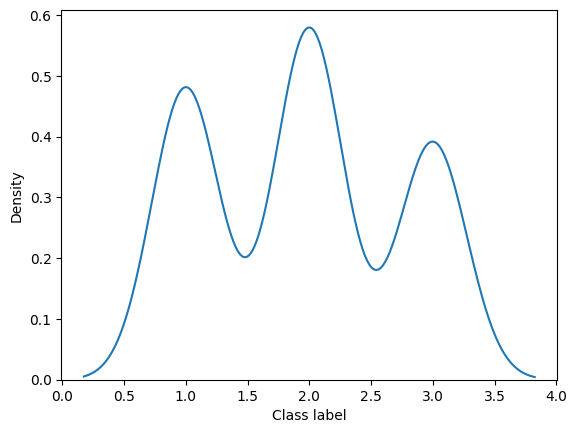

In [6]:
sns.kdeplot(df["Class label"])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

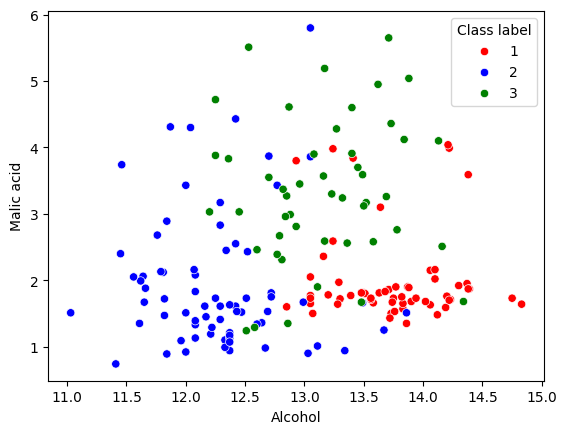

In [7]:
color_dict = {1:"red",3:"green",2:"blue"}
sns.scatterplot(x=df["Alcohol"],y=df["Malic acid"],hue=df["Class label"],palette=color_dict)

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(df.drop("Class label", axis=1),df["Class label"],test_size=0.3,random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [10]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [17]:
np.round(X_train_scaled.describe(),1)  # scale karne se min value 0 and max ho gaya 1 dono ka.

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


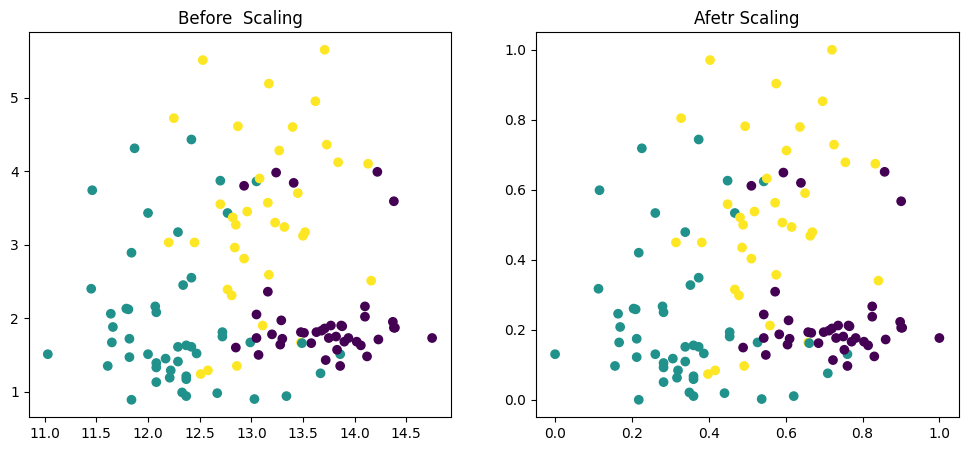

In [12]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train["Alcohol"], X_train["Malic acid"],c=y_train)
ax1.set_title("Before  Scaling")
ax2.scatter(X_train_scaled["Alcohol"], X_train_scaled["Malic acid"],c=y_train)
ax2.set_title("Afetr Scaling")
plt.show()

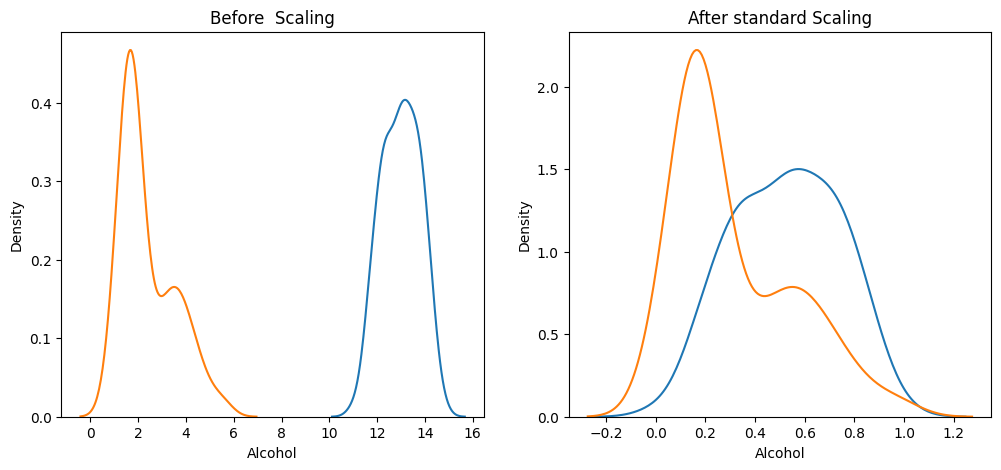

In [13]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))  # blue alcohol and orange wala Malic acid hain

# before scaling

ax1.set_title("Before  Scaling")
sns.kdeplot(X_train["Alcohol"], ax = ax1)
sns.kdeplot(X_train["Malic acid"], ax=ax1)

# after scaling
ax2.set_title("After standard Scaling")
sns.kdeplot(X_train_scaled["Alcohol"], ax = ax2)
sns.kdeplot(X_train_scaled["Malic acid"], ax=ax2)
plt.show()


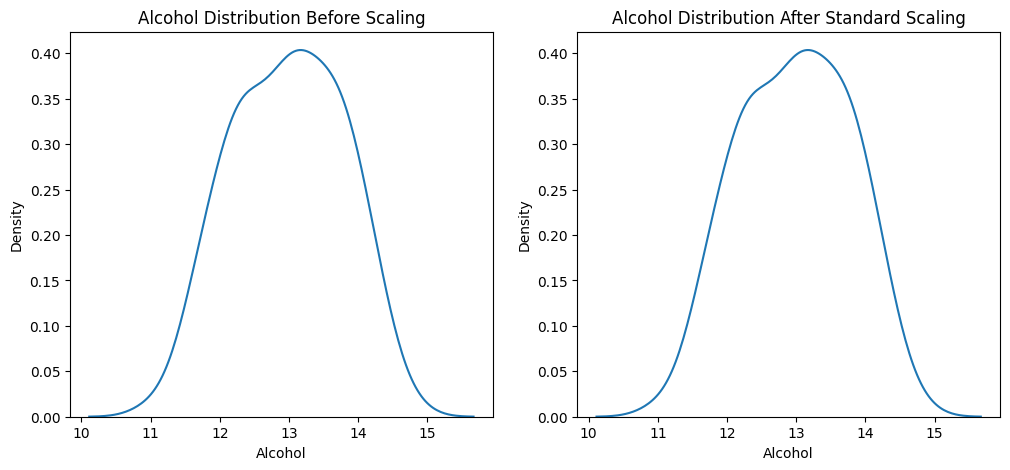

In [14]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize = (12,5))

# before scaling 
ax1.set_title("Alcohol Distribution Before Scaling")
sns.kdeplot(X_train["Alcohol"], ax=ax1)

# after scaling
ax2.set_title("Alcohol Distribution After Standard Scaling")
sns.kdeplot(X_train["Alcohol"], ax=ax2)
plt.show()

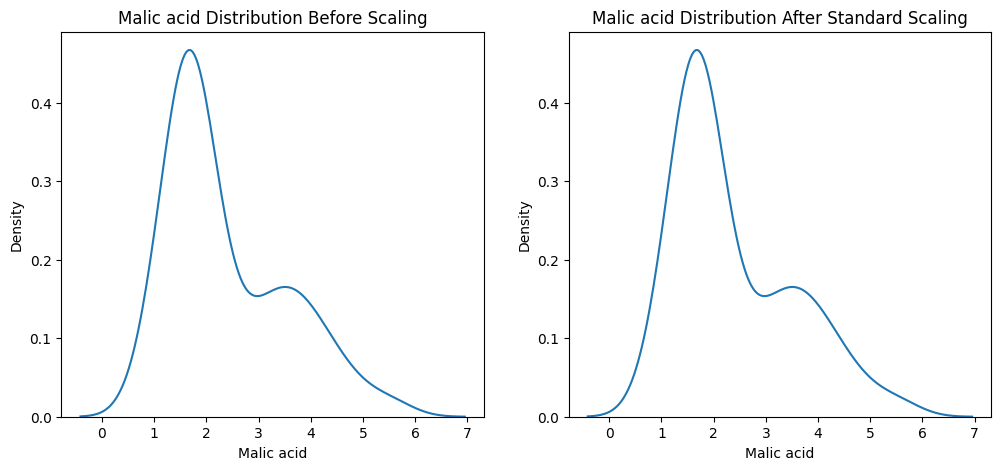

In [15]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize = (12,5))

# before scaling 
ax1.set_title("Malic acid Distribution Before Scaling")
sns.kdeplot(X_train["Malic acid"], ax=ax1)

# after scaling
ax2.set_title("Malic acid Distribution After Standard Scaling")
sns.kdeplot(X_train["Malic acid"], ax=ax2)
plt.show()